# Machine Learning Classification Pipeline
## Complete Supervised Learning Workflow
**Author:** [Your Name]
**Date:** 2024

### Pipeline Steps:
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Model Training (Random Forest & SVM)
5. Hyperparameter Tuning with GridSearchCV
6. Model Evaluation & Comparison
7. Cross-Validation
8. Final Model Selection & Saving

In [22]:
# ============================================
# CELL 1: IMPORTS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_iris
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"Python: {pd.__version__}, NumPy: {np.__version__}, Sklearn: {sklearn.__version__}")

✅ All imports successful!
Python: 3.0.3, NumPy: 2.5.1, Sklearn: 1.9.0


📊 Dataset Shape: (150, 6)
📋 Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

✅ Missing Values: 0

📈 Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


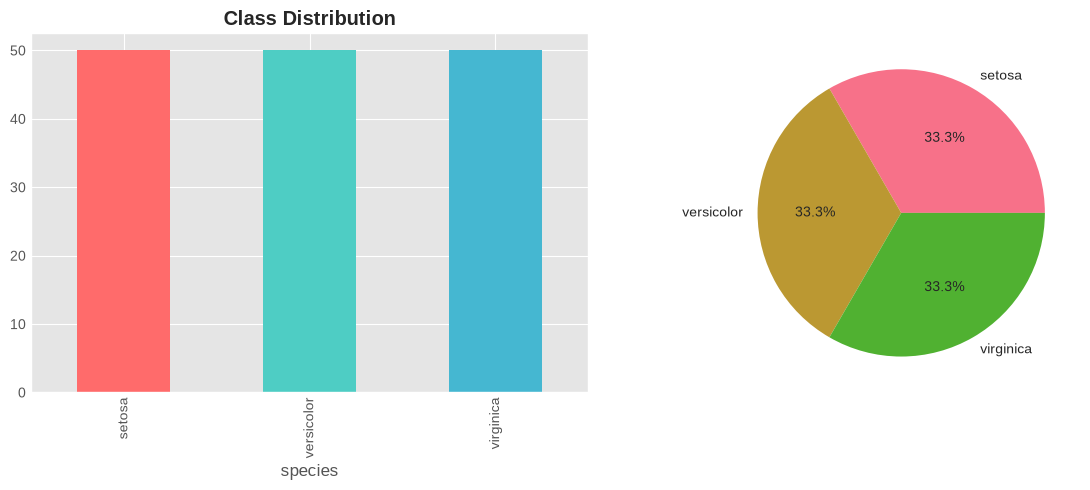

In [23]:
# ============================================
# CELL 2: LOAD & EXPLORE DATA
# ============================================
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Features: {list(df.columns)}")
print(f"\n✅ Missing Values: {df.isnull().sum().sum()}")
print(f"\n📈 Class Distribution:")
print(df['species'].value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['species'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Class Distribution', fontweight='bold')
df['species'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [24]:
# ============================================
# CELL 3: PREPROCESSING
# ============================================
X = df.iloc[:, :-2]
y = df['target']

# Add artificial missing values
np.random.seed(42)
mask = np.random.random(X.shape) < 0.05
X_masked = X.copy()
X_masked[mask] = np.nan

print(f"Missing values added:\n{X_masked.isnull().sum()}\n")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_masked, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")

# Preprocessing pipeline
numeric_features = X.columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)]
)

print("✅ Preprocessing pipeline created!")

Missing values added:
sepal length (cm)    11
sepal width (cm)      7
petal length (cm)     9
petal width (cm)      9
dtype: int64

✅ Training set: (120, 4)
✅ Test set: (30, 4)
✅ Preprocessing pipeline created!


In [25]:
# ============================================
# CELL 4: TRAIN BASELINE MODELS
# ============================================
# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# SVM Pipeline
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=True))
])

print("🔄 Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("🔄 Training SVM...")
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"\n📊 BASELINE RESULTS:")
print(f"✅ Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"✅ SVM Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")

🔄 Training Random Forest...
🔄 Training SVM...

📊 BASELINE RESULTS:
✅ Random Forest Accuracy: 0.9333 (93.33%)
✅ SVM Accuracy: 0.9333 (93.33%)


In [26]:
# ============================================
# CELL 5: HYPERPARAMETER TUNING
# ============================================
print("="*60)
print("🔄 HYPERPARAMETER TUNING WITH GridSearchCV")
print("="*60)

# Random Forest Tuning
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

print("\n1️⃣ Tuning Random Forest...")
rf_grid_search = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid_search.fit(X_train, y_train)
rf_best = rf_grid_search.best_estimator_
rf_best_pred = rf_best.predict(X_test)
rf_best_acc = accuracy_score(y_test, rf_best_pred)

print(f"✅ Best RF Params: {rf_grid_search.best_params_}")
print(f"✅ Best RF CV Score: {rf_grid_search.best_score_:.4f}")
print(f"✅ Best RF Test Accuracy: {rf_best_acc:.4f} ({rf_best_acc*100:.2f}%)")

# SVM Tuning
svm_param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.1],
    'classifier__kernel': ['rbf', 'linear']
}

print("\n2️⃣ Tuning SVM...")
svm_grid_search = GridSearchCV(
    svm_pipeline, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
svm_grid_search.fit(X_train, y_train)
svm_best = svm_grid_search.best_estimator_
svm_best_pred = svm_best.predict(X_test)
svm_best_acc = accuracy_score(y_test, svm_best_pred)

print(f"✅ Best SVM Params: {svm_grid_search.best_params_}")
print(f"✅ Best SVM CV Score: {svm_grid_search.best_score_:.4f}")
print(f"✅ Best SVM Test Accuracy: {svm_best_acc:.4f} ({svm_best_acc*100:.2f}%)")

🔄 HYPERPARAMETER TUNING WITH GridSearchCV

1️⃣ Tuning Random Forest...
✅ Best RF Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
✅ Best RF CV Score: 0.9667
✅ Best RF Test Accuracy: 0.9333 (93.33%)

2️⃣ Tuning SVM...
✅ Best SVM Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
✅ Best SVM CV Score: 0.9750
✅ Best SVM Test Accuracy: 0.9667 (96.67%)


In [27]:
# ============================================
# CELL 6: SELECT BEST MODEL
# ============================================
# Compare and select best model
if svm_best_acc >= rf_best_acc:
    best_model = svm_best
    best_model_name = "SVM (Tuned)"
    best_acc = svm_best_acc
else:
    best_model = rf_best
    best_model_name = "Random Forest (Tuned)"
    best_acc = rf_best_acc

print("="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🎯 Test Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📈 Improvement: {((best_acc - min(rf_acc, svm_acc)) * 100):.2f}%")
print("="*60)

# Cross-Validation of Best Model
cv_scores = cross_val_score(best_model, X_train, y_train, cv=10, scoring='accuracy')
print(f"\n📊 10-Fold Cross-Validation:")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

🏆 BEST MODEL: SVM (Tuned)
🎯 Test Accuracy: 0.9667 (96.67%)
📈 Improvement: 3.33%

📊 10-Fold Cross-Validation:
Mean CV Score: 0.9750 (+/- 0.1067)


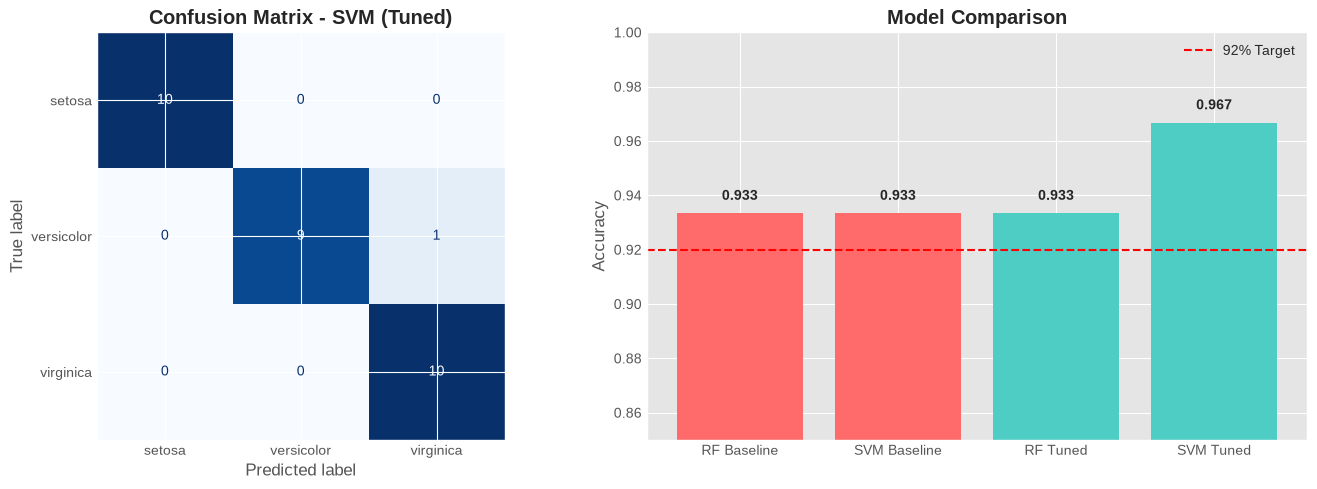


📋 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [28]:
# ============================================
# CELL 7: EVALUATION & VISUALIZATION
# ============================================
# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, 
    display_labels=iris.target_names, 
    ax=ax[0], cmap='Blues', colorbar=False
)
ax[0].set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')

# Model Comparison
models = ['RF Baseline', 'SVM Baseline', 'RF Tuned', 'SVM Tuned']
accuracies = [rf_acc, svm_acc, rf_best_acc, svm_best_acc]
colors = ['#FF6B6B', '#FF6B6B', '#4ECDC4', '#4ECDC4']

ax[1].bar(models, accuracies, color=colors)
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Model Comparison', fontweight='bold')
ax[1].set_ylim([0.85, 1.0])
ax[1].axhline(y=0.92, color='red', linestyle='--', label='92% Target')
ax[1].legend()

# Add values on bars
for i, v in enumerate(accuracies):
    ax[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_model.predict(X_test), target_names=iris.target_names))

In [29]:
# ============================================
# CELL 8: SAVE MODEL & SUMMARY
# ============================================
# Save best model
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')
print("✅ Best model saved as 'models/best_model.pkl'")

# Sample prediction
print("\n🔍 Sample Predictions:")
for i in range(5):
    pred = best_model.predict(X_test.iloc[i:i+1])[0]
    actual = y_test.iloc[i]
    status = "✅" if pred == actual else "❌"
    print(f"  {status} Predicted: {iris.target_names[pred]:12} | Actual: {iris.target_names[actual]}")

print("\n" + "="*60)
print("🎉 MACHINE LEARNING CLASSIFICATION PIPELINE COMPLETED!")
print("="*60)
print(f"🏆 Best Model: {best_model_name}")
print(f"🎯 Test Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📊 CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"📈 Improvement: {((best_acc - min(rf_acc, svm_acc)) * 100):.2f}%")
print(f"🔗 GitHub: github.com/amirkhan421")
print("="*60)

✅ Best model saved as 'models/best_model.pkl'

🔍 Sample Predictions:
  ✅ Predicted: setosa       | Actual: setosa
  ✅ Predicted: virginica    | Actual: virginica
  ✅ Predicted: versicolor   | Actual: versicolor
  ✅ Predicted: versicolor   | Actual: versicolor
  ✅ Predicted: setosa       | Actual: setosa

🎉 MACHINE LEARNING CLASSIFICATION PIPELINE COMPLETED!
🏆 Best Model: SVM (Tuned)
🎯 Test Accuracy: 0.9667 (96.67%)
📊 CV Score: 0.9750 (+/- 0.1067)
📈 Improvement: 3.33%
🔗 GitHub: github.com/amirkhan421
